In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from tqdm import tqdm
from mMIMO_sys import MassiveMIMOSystem
from benchmark import QNNScheduler, CNNScheduler
from QRL import QRLAgent
from plot import plot_training, plot_users, plot_antennas, plot_snr, plot_all 

import warnings
warnings.filterwarnings("ignore")

# EXPERIMENT 1 – TRAINING CONVERGENCE  (Fig. 3)

In [9]:
def run_training_convergence(A=32, T=6, snr_db=20, n_epochs=500,
                             batch_size=20, seed=42):
    np.random.seed(seed)
    
    # 1. Khởi tạo Môi trường và Agent
    sys = MassiveMIMOSystem(A=A, T=T, snr_db=snr_db)
    sys.reset_channel_conditions()  # CHÚ Ý: Cố định vị trí user (Large-scale fading)
    
    # Dùng QRLAgent phiên bản mới (VQC + Grover)
    agent = QRLAgent(A=A, T=T, lr=0.1, G=2) 
    
    n_schedule = T // 2   # Chỉ schedule một nửa số user
    raw_rates, smooth_rates = [], []
    alpha, ema = 0.1, None
    
    print(f"\n[Exp 1] Training Hybrid QRL — A={A}, T={T}, SNR={snr_db}dB, "
          f"epochs={n_epochs}, batch={batch_size}, n_schedule={n_schedule}")

    for ep in tqdm(range(n_epochs), desc="Training", ncols=70):
        # 2. Lấy mẫu kênh truyền tức thời (Small-scale fading)
        N = sys.generate_channel()
        F = sys.beamforming_vector(N)
        
        # -------------------------------------------------------------
        # KHÂU 1: ORACLE ĐÁNH GIÁ (Mô phỏng duyệt không gian của Grover)
        # -------------------------------------------------------------
        candidates = []
        for _ in range(batch_size):
            # Lấy ngẫu nhiên các chiến lược lập lịch (chọn n_schedule user)
            theta_cand = np.zeros(T, dtype=int)
            theta_cand[np.random.choice(T, n_schedule, replace=False)] = 1
            
            # Tính phần thưởng giả định
            sinr_cand = sys.compute_sinr(N, F, theta_cand)
            rates_cand = sys.instantaneous_rate(sinr_cand)
            reward_cand = sys.compute_pf_reward(rates_cand, theta_cand)
            
            # Chuyển mảng nhị phân thành số thập phân (idx) để đưa vào mạch
            idx = int(''.join(map(str, theta_cand.tolist())), 2)
            candidates.append((idx, reward_cand))
            
        # Tính ngưỡng tau (chọn top 25% chiến lược tốt nhất batch)
        rewards = [r for _, r in candidates]
        tau = np.percentile(rewards, 75)
        marked_list = [idx for idx, r in candidates if r >= tau]

        # -------------------------------------------------------------
        # KHÂU 2: GROVER KHUẾCH ĐẠI & ĐO LƯỜNG (Amplitude Amplification)
        # -------------------------------------------------------------
        # Agent dùng mạch Grover để khuếch đại xác suất của marked_list và chọn theta
        theta = agent.select(N, marked_list, n_schedule)
        
        # -------------------------------------------------------------
        # KHÂU 3: THỰC THI & CẬP NHẬT TRỌNG SỐ (RL Update)
        # -------------------------------------------------------------
        sinr = sys.compute_sinr(N, F, theta)
        rates = sys.instantaneous_rate(sinr)
        pf_reward = sys.compute_pf_reward(rates, theta)
        sys.update_avg_rate(rates, theta)  # Cập nhật state của Proportional Fairness
        
        # Học lại phân bố (Khóa chặt hành vi bằng Parameter-shift)
        agent.update(N, pf_reward, theta)

        # -------------------------------------------------------------
        # EVALUATION (Đánh giá Tốc độ Tổng - Sum Rate)
        # -------------------------------------------------------------
        N_eval = sys.generate_channel()
        F_eval = sys.beamforming_vector(N_eval)
        
        # Lúc Inference/Test, VQC đã được học đủ thông minh, không cần Oracle hỗ trợ
        theta_eval = agent.select(N_eval, marked_list=[], n_schedule=n_schedule)
        
        sinr_eval = sys.compute_sinr(N_eval, F_eval, theta_eval)
        eval_rate = float(np.sum(sys.instantaneous_rate(sinr_eval)))

        raw_rates.append(eval_rate)
        ema = eval_rate if ema is None else (1 - alpha) * ema + alpha * eval_rate
        smooth_rates.append(ema)

    return raw_rates, smooth_rates

train_data = run_training_convergence(
    A=32, T=6, snr_db=20, n_epochs=500, batch_size=20, seed=42)


[Exp 1] Training Hybrid QRL — A=32, T=6, SNR=20dB, epochs=500, batch=20, n_schedule=3


Training:   0%|                               | 0/500 [00:00<?, ?it/s]

Training:   4%|▊                     | 19/500 [00:15<06:44,  1.19it/s]


KeyboardInterrupt: 

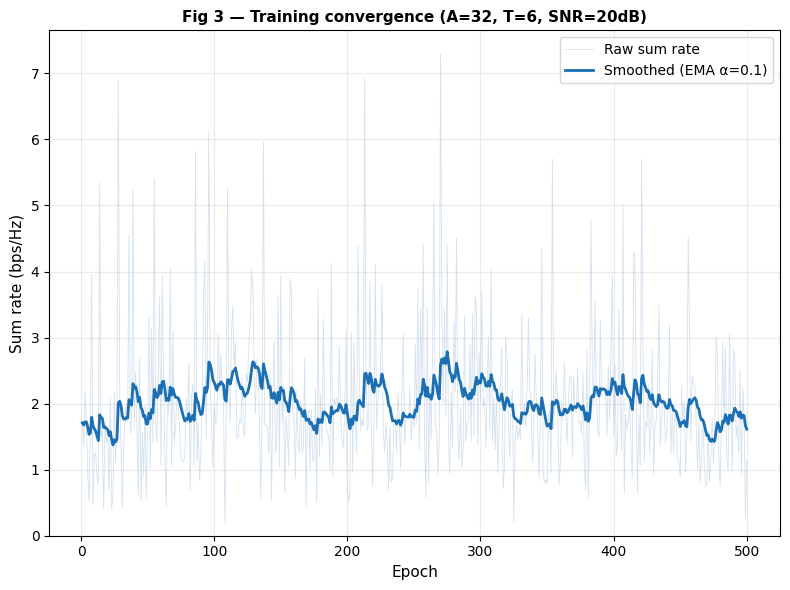

In [4]:
plot_training(train_data)

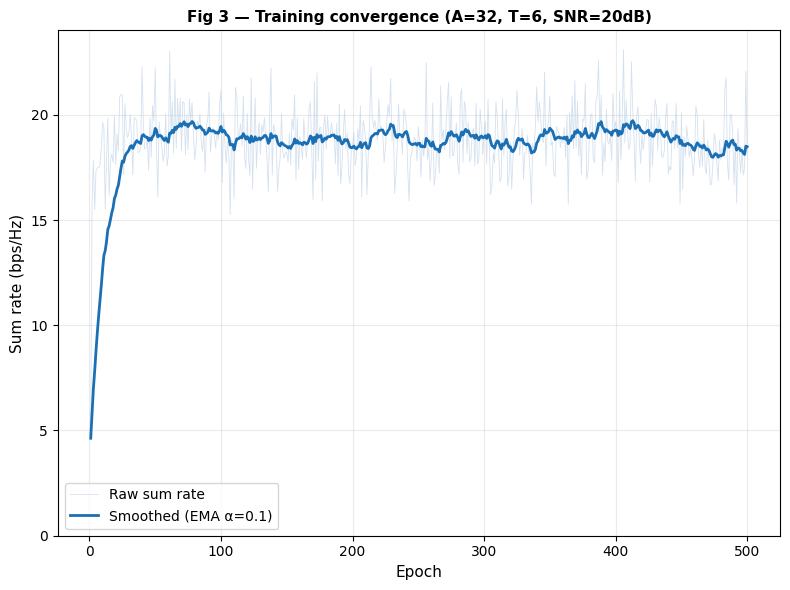

In [9]:
plot_training(train_data)

# EXPERIMENT 2 – SUM RATE vs. NUMBER OF USERS  (Fig. 4)

In [12]:
def run_vs_users(A=32, snr_db=20, user_range=None,
                 n_train=300, batch_size=20, seed=0):
    if user_range is None:
        user_range = [2, 4, 6, 8, 10]
    results = {'QRL': [], 'CNN': [], 'QNN': []}
    print(f"\n[Exp 2] Sum rate vs users | A={A}, SNR={snr_db}dB")
 
    for T in user_range:
        np.random.seed(seed + T)
        sys_q = MassiveMIMOSystem(A=A, T=T, snr_db=snr_db)
        sys_c = MassiveMIMOSystem(A=A, T=T, snr_db=snr_db)
        sys_n = MassiveMIMOSystem(A=A, T=T, snr_db=snr_db)
        for s in (sys_c, sys_n):
            s.aod = sys_q.aod.copy(); s.n_LoS = sys_q.n_LoS.copy(); s.L = sys_q.L.copy()
 
        agent = QRLAgent(T=T, lr=0.3, grover_iter=2)
        cnn   = CNNScheduler(A=A, T=T)
        qnn   = QNNScheduler(A=A, T=T, n_layers=1)
        n_schedule = max(1, T // 2)
 
        for ep in range(n_train):
            N = sys_q.generate_channel()           # Fix Bug 2: 1 channel chung
            F = sys_q.beamforming_vector(N)
 
            _one_qrl_epoch(agent, sys_q, N, F, T, batch_size)   # Fixes 1,2,4,5
 
            theta_c = cnn.select(N, n_schedule)
            sinr_c  = sys_c.compute_sinr(N, F, theta_c)
            rates_c = sys_c.instantaneous_rate(sinr_c)
            cnn.update(N, sys_c.compute_pf_reward(rates_c, theta_c))
            sys_c.update_avg_rate(rates_c, theta_c)
 
            theta_n = qnn.select(N, n_schedule)
            sinr_n  = sys_n.compute_sinr(N, F, theta_n)
            rates_n = sys_n.instantaneous_rate(sinr_n)
            qnn.update(N, sys_n.compute_pf_reward(rates_n, theta_n), theta=theta_n)
            sys_n.update_avg_rate(rates_n, theta_n)
 
        eval_r = _eval_sum_rate(agent, cnn, qnn, sys_q, sys_c, sys_n, n_schedule)  # Fix Bug 3
        for m in results: results[m].append(eval_r[m])
        print(f"  T={T:2d} | QRL={eval_r['QRL']:.2f}  QNN={eval_r['QNN']:.2f}  CNN={eval_r['CNN']:.2f}")
 
    return user_range, results

users_data = run_vs_users(
        A=32, snr_db=20, user_range=[2, 4, 6, 8, 10],
        n_train=300, batch_size=10, seed=0
    )


[Exp 2] Sum rate vs users | A=32, SNR=20dB
  T= 2 | QRL=9.40  QNN=9.87  CNN=9.62
  T= 4 | QRL=13.80  QNN=2.00  CNN=10.27
  T= 6 | QRL=19.53  QNN=19.79  CNN=19.67
  T= 8 | QRL=21.44  QNN=16.76  CNN=18.02


KeyboardInterrupt: 

In [ ]:
users_data = run_vs_users(
        A=32, snr_db=20, user_range=[2, 4, 6, 8, 10],
        n_train=300, batch_size=10, seed=0
    )
# 36m


[Exp 2] Sum rate vs users — A=32, SNR=20dB
  T= 2 | QRL=9.51  QNN=9.51  CNN=9.51 bps/Hz
  T= 4 | QRL=13.59  QNN=14.36  CNN=13.43 bps/Hz
  T= 6 | QRL=17.56  QNN=16.36  CNN=16.91 bps/Hz
  T= 8 | QRL=22.09  QNN=18.13  CNN=17.18 bps/Hz
  T=10 | QRL=23.24  QNN=22.90  CNN=19.84 bps/Hz


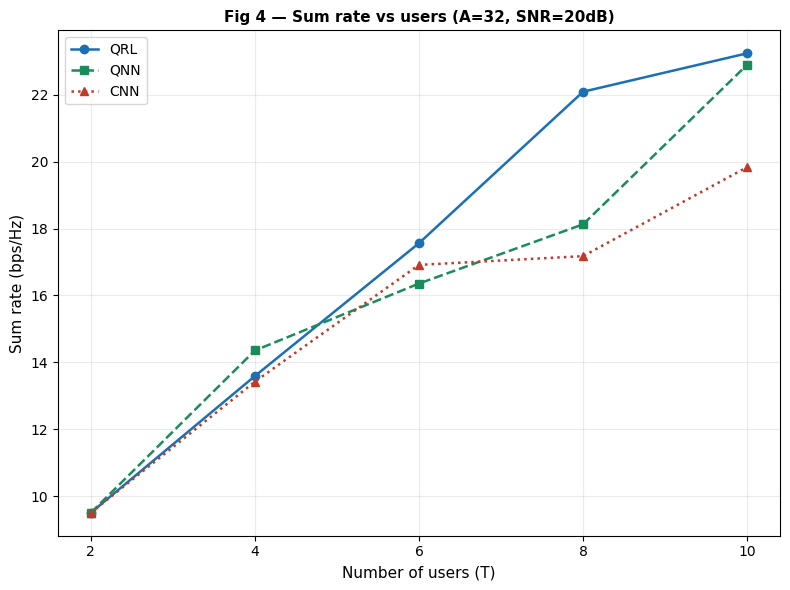

In [10]:
plot_users(users_data)

# EXPERIMENT 3 – SUM RATE vs. NUMBER OF ANTENNAS  (Fig. 5)

In [ ]:
def run_vs_antennas(T=6, snr_db=20, ant_range=None,
                    n_train=300, batch_size=10, seed=1):
    """
    Fig. 5: T=6 fixed, SNR=20dB fixed, sweep A ∈ {6,8,10,12,14,16}.

    Fixes vs original:
      1. lr=0.05  — tránh overshoot policy_probs
      2. batch channel riêng — mỗi QRL sample dùng channel độc lập
      3. update_avg_rate bên trong batch loop — PF memory đúng
      4. Ép n_schedule users cho QRL — fair comparison với CNN/QNN
      5. Dùng chung F vì sys_c, sys_n có cùng spatial params với sys_q
      6. sys_c/sys_n dùng F riêng tính từ N — đúng về mặt vật lý
         (beamforming_vector là deterministic với cùng N, aod, L nên
          F_q == F_c == F_n; dùng chung 1 biến cho gọn)
    """
    if ant_range is None:
        ant_range = [6, 8, 10, 12, 14, 16]

    results = {'QRL': [], 'CNN': [], 'QNN': []}

    print(f"\n[Exp 3] Sum rate vs antennas — T={T}, SNR={snr_db}dB")

    for A in ant_range:
        np.random.seed(seed + A)

        # 3 sys riêng để PF state độc lập, copy spatial params để fair
        sys_q = MassiveMIMOSystem(A=A, T=T, snr_db=snr_db)
        sys_c = MassiveMIMOSystem(A=A, T=T, snr_db=snr_db)
        sys_n = MassiveMIMOSystem(A=A, T=T, snr_db=snr_db)
        for s in (sys_c, sys_n):
            s.aod   = sys_q.aod.copy()
            s.n_LoS = sys_q.n_LoS.copy()
            s.L     = sys_q.L.copy()

        # Fix 1: lr=0.05 thay vì 0.3
        agent = QRLAgent(T=T, lr=0.05, grover_iter=2)
        cnn   = CNNScheduler(A=A, T=T)
        qnn   = QNNScheduler(A=A, T=T)

        n_schedule = max(1, T // 2)

        for ep in range(n_train):
            # Channel chung cho CNN và QNN (1 realization mỗi epoch)
            N = sys_q.generate_channel()
            # Vì cùng spatial params, F giống nhau cho cả 3 sys
            F = sys_q.beamforming_vector(N)

            # ── QRL: mỗi sample trong batch có channel riêng ────────────
            batch = []
            for _ in range(batch_size):
                theta_q, idx = agent.select_action()

                # Fix 4: ép đúng n_schedule users — fair với CNN/QNN
                if theta_q.sum() != n_schedule:
                    theta_q = np.zeros(T, dtype=int)
                    theta_q[np.random.choice(T, n_schedule, replace=False)] = 1
                    idx = int(''.join(map(str, theta_q.tolist())), 2)

                # Fix 2: channel riêng cho mỗi QRL sample
                N_b = sys_q.generate_channel()
                F_b = sys_q.beamforming_vector(N_b)

                sinr_q  = sys_q.compute_sinr(N_b, F_b, theta_q)
                rates_q = sys_q.instantaneous_rate(sinr_q)
                pf_q    = sys_q.compute_pf_reward(rates_q, theta_q)

                # Fix 3: update PF memory ngay trong batch loop
                sys_q.update_avg_rate(rates_q, theta_q)

                batch.append((idx, pf_q))

            agent.update_batch(batch)

            # ── CNN ─────────────────────────────────────────────────────
            theta_c = cnn.select(N, n_schedule)
            sinr_c  = sys_c.compute_sinr(N, F, theta_c)
            rates_c = sys_c.instantaneous_rate(sinr_c)
            pf_c    = sys_c.compute_pf_reward(rates_c, theta_c)
            cnn.update(N, pf_c)
            sys_c.update_avg_rate(rates_c, theta_c)

            # ── QNN ─────────────────────────────────────────────────────
            theta_n = qnn.select(N, n_schedule)
            sinr_n  = sys_n.compute_sinr(N, F, theta_n)
            rates_n = sys_n.instantaneous_rate(sinr_n)
            pf_n    = sys_n.compute_pf_reward(rates_n, theta_n)
            qnn.update(N, pf_n, theta=theta_n)
            sys_n.update_avg_rate(rates_n, theta_n)

        eval_r = _eval_sum_rate(agent, cnn, qnn, sys_q, n_schedule, n_test=200)
        for m in results:
            results[m].append(eval_r[m])

        print(f"  A={A:2d} | QRL={eval_r['QRL']:.2f}  "
              f"QNN={eval_r['QNN']:.2f}  CNN={eval_r['CNN']:.2f} bps/Hz")

    return ant_range, results

In [ ]:
ant_data = run_vs_antennas(
        T=6, snr_db=20, ant_range=[6, 8, 10, 12, 14, 16],
        n_train=300, batch_size=10, seed=1
    )
# 14m


[Exp 3] Sum rate vs antennas — T=6, SNR=20dB
  A= 6 | QRL=6.25  QNN=6.60  CNN=6.38 bps/Hz
  A= 8 | QRL=11.49  QNN=7.36  CNN=10.30 bps/Hz
  A=10 | QRL=10.61  QNN=7.84  CNN=10.12 bps/Hz
  A=12 | QRL=14.83  QNN=11.52  CNN=9.45 bps/Hz
  A=14 | QRL=13.06  QNN=13.08  CNN=10.54 bps/Hz
  A=16 | QRL=10.34  QNN=11.40  CNN=12.01 bps/Hz


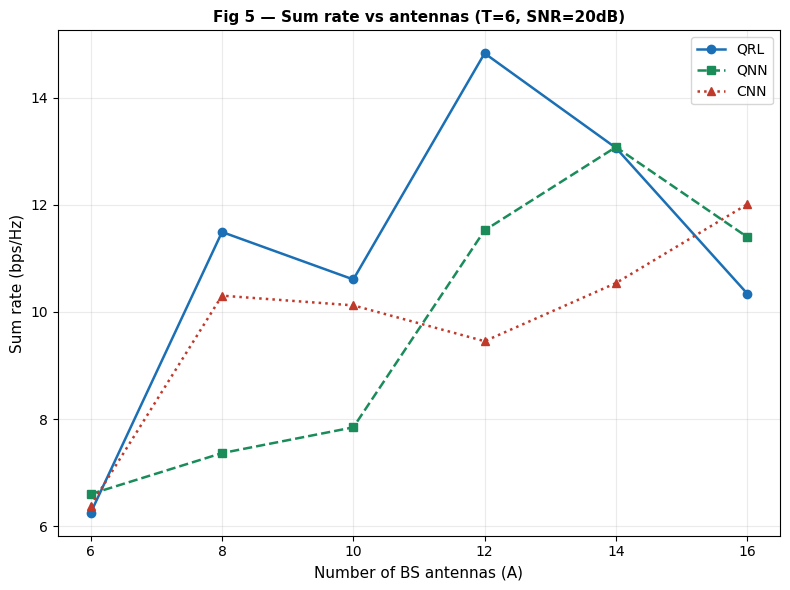

In [13]:
plot_antennas(ant_data)

# EXPERIMENT 4 – SUM RATE vs. SNR  (Fig. 6)

In [ ]:
def run_vs_snr(configs=None, snr_range=None,
               n_train=250, batch_size=10, seed=2):
    """
    Fig. 6: Two (T, A) configs × SNR sweep ∈ {0,5,10,15,20,25,30} dB.
    Each (T,A,SNR) point trains from scratch — no leakage across SNR levels.

    Fixes vs original:
      1. Xóa sys thừa (MassiveMIMOSystem tạo lần 4 không dùng đến)
      2. _eval_sum_rate dùng sys_q thay vì sys (sys không tồn tại sau fix 1)
      3. lr=0.05 thay vì 0.3
      4. batch channel riêng cho mỗi QRL sample
      5. update_avg_rate trong batch loop thay vì sau batch
      6. Ép đúng n_schedule users cho QRL
      7. Dùng chung F vì spatial params giống nhau
      8. seed dùng hash ổn định thay vì cộng số nguyên
         (seed+0+4+8 == seed+5+4+3 — trùng seed giữa các config!)
    """
    if configs is None:
        configs = [(4, 8), (6, 12)]
    if snr_range is None:
        snr_range = [0, 5, 10, 15, 20, 25, 30]

    all_results = {}

    print("\n[Exp 4] Sum rate vs SNR")

    for (T, A) in configs:
        results = {'QRL': [], 'CNN': [], 'QNN': []}

        for snr_db in snr_range:
            # Fix 8: seed unique thực sự cho mỗi (T, A, SNR)
            # Cộng số nguyên bị trùng: e.g. seed+0+4+8 == seed+5+4+3
            np.random.seed(seed + hash((T, A, snr_db)) % (2**31))

            # Fix 1: bỏ sys thừa — chỉ cần sys_q, sys_c, sys_n
            sys_q = MassiveMIMOSystem(A=A, T=T, snr_db=snr_db)
            sys_c = MassiveMIMOSystem(A=A, T=T, snr_db=snr_db)
            sys_n = MassiveMIMOSystem(A=A, T=T, snr_db=snr_db)
            for s in (sys_c, sys_n):
                s.aod   = sys_q.aod.copy()
                s.n_LoS = sys_q.n_LoS.copy()
                s.L     = sys_q.L.copy()

            # Fix 3: lr=0.05
            agent = QRLAgent(T=T, lr=0.05, grover_iter=2)
            cnn   = CNNScheduler(A=A, T=T)
            qnn   = QNNScheduler(A=A, T=T)

            n_schedule = max(1, T // 2)

            # ── Training ─────────────────────────────────────────────────
            for ep in range(n_train):
                # Channel chung cho CNN và QNN
                N = sys_q.generate_channel()
                # Fix 7: dùng chung F (spatial params giống nhau)
                F = sys_q.beamforming_vector(N)

                # ── QRL: mỗi sample có channel riêng ────────────────────
                batch = []
                for _ in range(batch_size):
                    theta_q, idx = agent.select_action()

                    # Fix 6: ép đúng n_schedule users
                    if theta_q.sum() != n_schedule:
                        theta_q = np.zeros(T, dtype=int)
                        theta_q[np.random.choice(T, n_schedule, replace=False)] = 1
                        idx = int(''.join(map(str, theta_q.tolist())), 2)

                    # Fix 4: channel riêng cho mỗi QRL sample
                    N_b = sys_q.generate_channel()
                    F_b = sys_q.beamforming_vector(N_b)

                    sinr_q  = sys_q.compute_sinr(N_b, F_b, theta_q)
                    rates_q = sys_q.instantaneous_rate(sinr_q)
                    pf_q    = sys_q.compute_pf_reward(rates_q, theta_q)

                    # Fix 5: update PF memory ngay trong batch loop
                    sys_q.update_avg_rate(rates_q, theta_q)

                    batch.append((idx, pf_q))

                agent.update_batch(batch)

                # ── CNN ──────────────────────────────────────────────────
                theta_c = cnn.select(N, n_schedule)
                sinr_c  = sys_c.compute_sinr(N, F, theta_c)
                rates_c = sys_c.instantaneous_rate(sinr_c)
                pf_c    = sys_c.compute_pf_reward(rates_c, theta_c)
                cnn.update(N, pf_c)
                sys_c.update_avg_rate(rates_c, theta_c)

                # ── QNN ──────────────────────────────────────────────────
                theta_n = qnn.select(N, n_schedule)
                sinr_n  = sys_n.compute_sinr(N, F, theta_n)
                rates_n = sys_n.instantaneous_rate(sinr_n)
                pf_n    = sys_n.compute_pf_reward(rates_n, theta_n)
                qnn.update(N, pf_n, theta=theta_n)
                sys_n.update_avg_rate(rates_n, theta_n)

            # ── Evaluation ───────────────────────────────────────────────
            # Fix 2: dùng sys_q thay vì sys (sys đã bị xóa ở fix 1)
            eval_r = _eval_sum_rate(agent, cnn, qnn, sys_q,
                                    n_schedule, n_test=80)
            for m in results:
                results[m].append(eval_r[m])

            print(f"  T={T},A={A},SNR={snr_db:2d}dB | "
                  f"QRL={eval_r['QRL']:.2f}  "
                  f"QNN={eval_r['QNN']:.2f}  "
                  f"CNN={eval_r['CNN']:.2f}")

        all_results[(T, A)] = results

    return snr_range, all_results, configs

In [15]:
snr_data = run_vs_snr(
        configs=[(4, 8), (6, 12)],
        snr_range=[0, 5, 10, 15, 20, 25, 30],
        n_train=250, batch_size=10, seed=2
    )


[Exp 4] Sum rate vs SNR
  T=4,A=8,SNR= 0dB | QRL=2.11  QNN=1.56  CNN=1.96
  T=4,A=8,SNR= 5dB | QRL=3.72  QNN=2.53  CNN=3.00
  T=4,A=8,SNR=10dB | QRL=5.81  QNN=3.74  CNN=4.20
  T=4,A=8,SNR=15dB | QRL=6.83  QNN=4.50  CNN=4.86
  T=4,A=8,SNR=20dB | QRL=8.43  QNN=4.45  CNN=5.86
  T=4,A=8,SNR=25dB | QRL=8.55  QNN=4.55  CNN=8.54
  T=4,A=8,SNR=30dB | QRL=9.26  QNN=4.60  CNN=9.28
  T=6,A=12,SNR= 0dB | QRL=3.57  QNN=3.53  CNN=3.20
  T=6,A=12,SNR= 5dB | QRL=6.40  QNN=6.23  CNN=5.74
  T=6,A=12,SNR=10dB | QRL=9.32  QNN=9.13  CNN=8.19
  T=6,A=12,SNR=15dB | QRL=11.34  QNN=11.10  CNN=10.79
  T=6,A=12,SNR=20dB | QRL=12.95  QNN=12.76  CNN=11.49
  T=6,A=12,SNR=25dB | QRL=13.72  QNN=13.23  CNN=11.47
  T=6,A=12,SNR=30dB | QRL=11.32  QNN=13.40  CNN=11.74


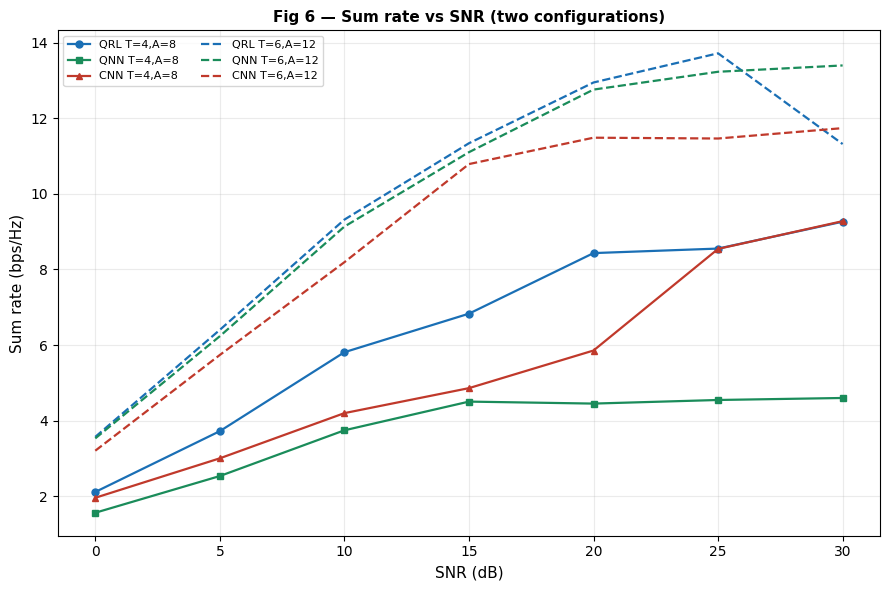

In [16]:
plot_snr(snr_data)

# Figures

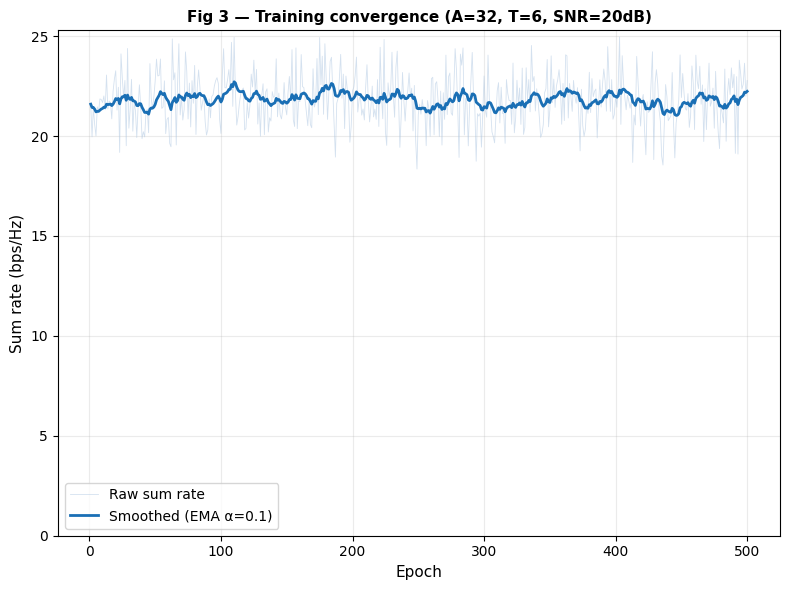

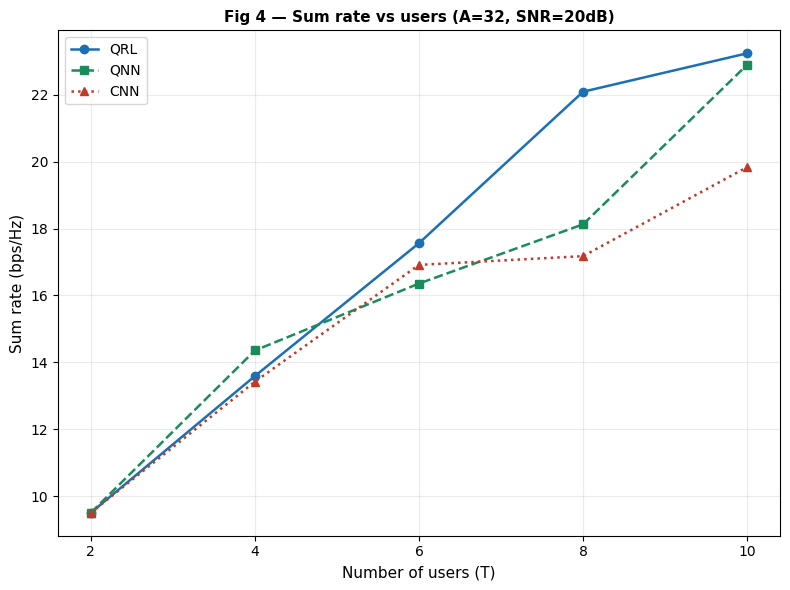

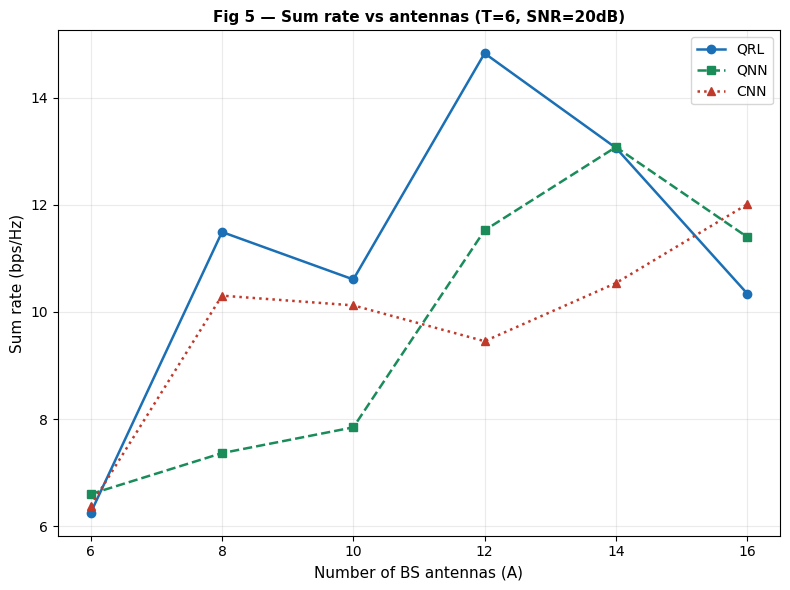

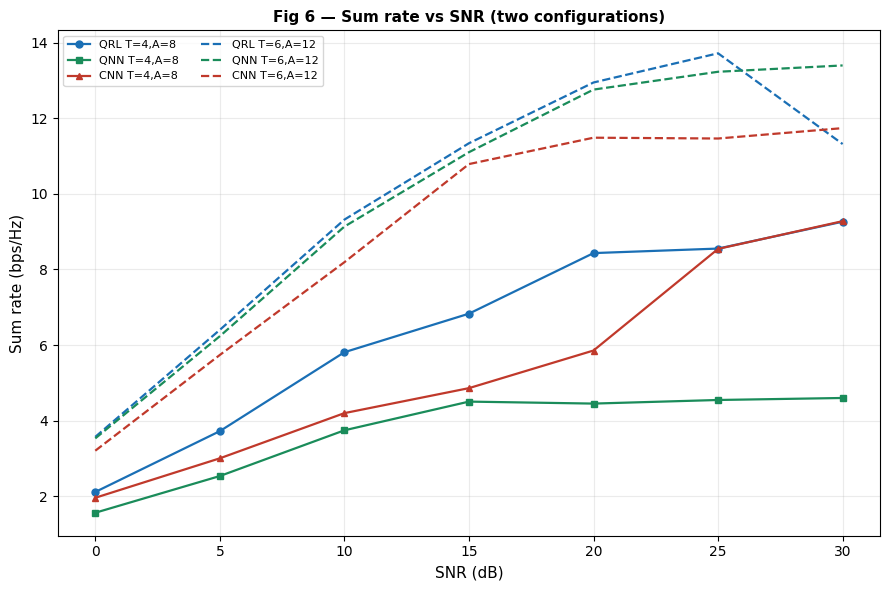

In [32]:
plot_all(train_data, users_data, ant_data, snr_data)